# Lab | Sequence Modeling with LSTM

In [ ]:
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip -q glove.6B.zip

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv('dataset.csv')  # Make sure your CSV file is in the correct path
text_col = 'Text'
label_col = 'Category'

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1490, 3)


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


# =============================================================================
# EXERCISE 1: TEXT PREPROCESSING
# =============================================================================

In [3]:

def clean_text(text):
    """
    Clean and preprocess text data
    TODO: Complete this function to:
    1. Convert text to lowercase
    2. Remove all characters except letters and spaces using regex
    3. Return the cleaned text
    """
    # TODO: Convert to lowercase
    text = text.lower()
    
    # TODO: Remove non-alphabetic characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    return text

# Apply text cleaning
df[text_col] = df[text_col].astype(str).apply(clean_text)

print("Sample cleaned texts:")
print(df[text_col].head(3).tolist())

Sample cleaned texts:
['worldcom exboss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness  cynthia cooper  worldcom s exhead of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in  her warnings led to the collapse of the firm following the discovery of an bn bn accounting fraud mr ebbers has pleaded not guilty to charges of fraud and conspiracy  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early  and  she said andersen had given a  green light  to the procedures and practices used by worldcom mr ebber s la

# =============================================================================
# EXERCISE 2: LABEL ENCODING
# =============================================================================


In [4]:

# TODO: Initialize LabelEncoder and encode the labels
encoder = LabelEncoder()
df[label_col] = encoder.fit_transform(df[label_col])

num_classes = len(encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {encoder.classes_}")


Number of classes: 5
Classes: ['business' 'entertainment' 'politics' 'sport' 'tech']



# =============================================================================
# EXERCISE 3: TEXT TOKENIZATION AND PADDING
# =============================================================================


In [5]:

# TODO: Initialize tokenizer with out-of-vocabulary token
tokenizer = Tokenizer(oov_token='<OOV>') # YOUR CODE HERE (use oov_token='<OOV>')

# TODO: Fit tokenizer on texts
tokenizer.fit_on_texts(df[text_col])

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
print(f"Vocabulary size: {vocab_size}")

# TODO: Convert texts to sequences
sequences = tokenizer.texts_to_sequences(df[text_col])

# TODO: Pad sequences to max_len=100
max_len = 100
padded = pad_sequences(sequences, maxlen=max_len, padding='post')  # YOUR CODE HERE (use pad_sequences with padding='post')

print(f"Padded sequences shape: {padded.shape}")


Vocabulary size: 25379
Padded sequences shape: (1490, 100)



# =============================================================================
# EXERCISE 4: TRAIN-VALIDATION-TEST SPLIT
# =============================================================================


In [6]:
# TODO: Split data into train (70%), validation (15%), and test (15%)
X = padded
y = df[label_col].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1043, 100), Val: (223, 100), Test: (224, 100)


# =============================================================================
# EXERCISE 5: LOAD PRE-TRAINED EMBEDDINGS (OPTIONAL)
# ============================================================================


In [7]:
# TODO: Load GloVe embeddings
embedding_dim = 100
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# =============================================================================
# EXERCISE 6: BUILD MODEL FUNCTION
# =============================================================================


In [8]:
# Build RNN or LSTM model
# TODO: Complete this function to build the neural network
def build_model(vocab_size, embedding_dim, max_len, num_classes, embedding_matrix=None, use_lstm=True):
    model = Sequential()
    
    if embedding_matrix is not None:
        model.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix],
                            input_length=max_len, trainable=False))
    else:
        model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))
    
    if use_lstm:
        model.add(LSTM(64, return_sequences=False))
    else:
        model.add(SimpleRNN(64))
    
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# =============================================================================
# EXERCISE 7: MODEL TRAINING AND EVALUATION
# =============================================================================


In [9]:
# TODO: Build model
model = build_model(vocab_size, embedding_dim, max_len, num_classes,
                    embedding_matrix=embedding_matrix, use_lstm=True)
model.summary()

# TODO: Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stop])

# TODO: Make predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# TODO: Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# TODO: Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,537,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,537,900 (9.68 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,537,900 (9.68 MB)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.2320 - loss: 1.6091 - val_accuracy: 0.2287 - val_loss: 1.6085
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2349 - loss: 1.6081 - val_accuracy: 0.2287 - val_loss: 1.6076
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2349 - loss: 1.6074 - val_accuracy: 0.2287 - val_loss: 1.6067
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2349 - loss: 1.6066 - val_accuracy: 0.2287 - val_loss: 1.6061
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2349 - loss: 1.6061 - val_accuracy: 0.2287 - val_loss: 1.6056
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2349 - loss: 1.6056 - val_accuracy: 0.2287 - val_loss: 1.6050
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2349 - loss: 1.6052 - val_accuracy: 0.2287 - val_loss: 1.6045
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2349 - loss: 1.6049 - val_accuracy: 0.2287 - v

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag


# =============================================================================
# EXERCISE 8: VISUALIZATION
# =============================================================================


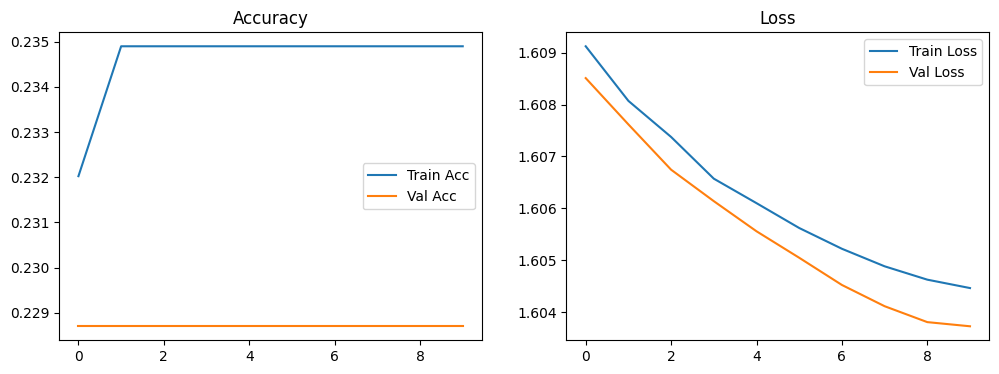

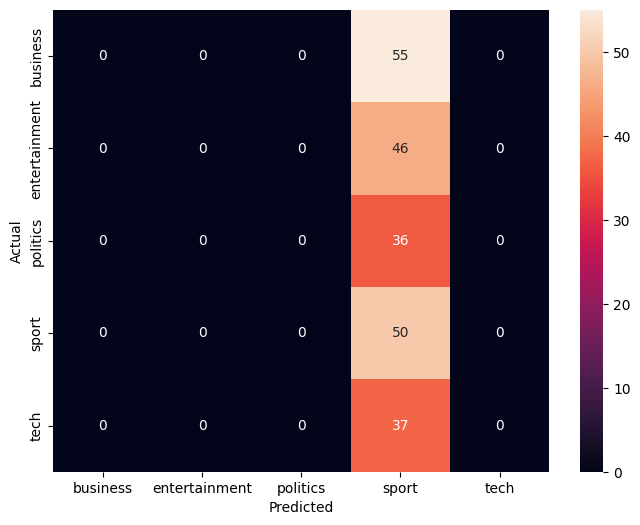

In [10]:
# TODO: Plot training accuracy
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

# TODO: Plot training loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# TODO: Plot confusion matrices
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# =============================================================================
# EXERCISE 9: RESULTS ANALYSIS
# =============================================================================


In [11]:
# TODO: Add best validation metrics to results
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best validation loss: {best_val_loss:.4f}")

Best validation accuracy: 0.2287
Best validation loss: 1.6037


EXERCISE COMPLETE!